In [20]:
%load_ext autoreload

In [21]:
%autoreload 2

In [34]:
import os
import pandas as pd
import json
from datetime import datetime
# import matplotlib.pyplot as plt
from tqdm import tqdm_notebook
import sys
from pprint import pprint

In [3]:
lad_project_path = "/Users/valentin.lapparov/PycharmProjects/code/ml/lad"
code_project_path = "/Users/valentin.lapparov/PycharmProjects/code"

In [13]:
for path in [code_project_path, lad_project_path]: 
    if path not in sys.path:
        sys.path.append(path)

In [14]:
from online.detectors.logfrequency.histogrambins.histogrambins import HistogramBins, LogFrequencyPoint

In [98]:
from ipynb.fs.full.Evaluation_script import ts_converter, get_incidents

In [138]:
client = "cwallet"
DATA_DIR = f"data/{client}"
EVALUATION_FOLDER = f"evaluation/{client}"
make_charts = False
# make_directory(EVALUATION_FOLDER, verbose=False)
logfrequency_data_dir = os.path.join(DATA_DIR, "logfrequency_data")

# deployments

lad_logfrequency_models_path = os.path.join(DATA_DIR, "lad_logfrequency_models.json")
lad_logfrequency_models = pd.read_json(lad_logfrequency_models_path)
lad_logfrequency_models["deployed models"] = lad_logfrequency_models["models"].apply(
    lambda x: ", ".join(x.keys())
)
lad_logfrequency_models["source"] = lad_logfrequency_models["topic"].apply(
    lambda x: x.replace("-log-", "-").replace("-stashed", "")
)
deployed_logfrequency_models = (
    lad_logfrequency_models[["source", "shape", "deployed models"]]
    .set_index("source")
    .to_dict(orient="index")
)

# DBSCAN

dbscan_file_path = os.path.join(DATA_DIR, "dbscan.csv")
dbscan_anomalies = pd.read_csv(dbscan_file_path,parse_dates=["datetime"],)

train_date_end = "2021-11-08 14:50:00"

In [139]:
dbscan_anomalies.head()

,timestamp,n_message,isAnomaly,source,datetime,value
0,1636553700,1117,True,60ed840f588aa700127280d6-linux60effb26a06f3200...,2021-11-10 14:15:00,1117
1,1636553760,1113,True,60ed840f588aa700127280d6-linux60effb26a06f3200...,2021-11-10 14:16:00,1113
2,1636554600,1498,True,60ed840f588aa700127280d6-linux60effb26a06f3200...,2021-11-10 14:30:00,1498
3,1636554660,1495,True,60ed840f588aa700127280d6-linux60effb26a06f3200...,2021-11-10 14:31:00,1495
4,1636557120,2333,True,60ed840f588aa700127280d6-linux60effb26a06f3200...,2021-11-10 15:12:00,2333


In [140]:
lad_logfrequency_models

,topic,shape,models,deployed models,source
0,60ed840f588aa700127280d6-linux60effb11a06f3200...,random noisy data,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...","HB, Skyline",60ed840f588aa700127280d6-linux60effb11a06f3200...
1,60ed840f588aa700127280d6-linux60effb30a06f3200...,usually the same values observed,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...",HB,60ed840f588aa700127280d6-linux60effb30a06f3200...
2,60ed840f588aa700127280d6-linux60effadaa06f3200...,random noisy data,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...","HB, Skyline",60ed840f588aa700127280d6-linux60effadaa06f3200...
3,60ed840f588aa700127280d6-linux60effadaa06f3200...,usually the same values observed,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...",HB,60ed840f588aa700127280d6-linux60effadaa06f3200...
4,60ed840f588aa700127280d6-linux60effa84a06f3200...,dense data around the mean value,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...","HB, Skyline",60ed840f588aa700127280d6-linux60effa84a06f3200...
5,60ed840f588aa700127280d6-linux60effb30a06f3200...,random noisy data,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...","HB, Skyline",60ed840f588aa700127280d6-linux60effb30a06f3200...
6,60ed840f588aa700127280d6-linux60effafba06f3200...,random noisy data,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...","HB, Skyline",60ed840f588aa700127280d6-linux60effafba06f3200...
7,60ed840f588aa700127280d6-linux60effa84a06f3200...,dense data around the mean value,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...","HB, Skyline",60ed840f588aa700127280d6-linux60effa84a06f3200...
8,60ed840f588aa700127280d6-linux60effb26a06f3200...,random noisy data,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...","HB, Skyline",60ed840f588aa700127280d6-linux60effb26a06f3200...
9,60ed840f588aa700127280d6-linux60effb11a06f3200...,usually the same values observed,"{'HB': {'max_bins': 5, 'alpha': 0.5, 'max_poin...",HB,60ed840f588aa700127280d6-linux60effb11a06f3200...


In [141]:
source_df = {}
for root, _, files in os.walk(logfrequency_data_dir):
    for file in tqdm_notebook(files):
        if file.endswith(".csv"):
            current_source = file.replace(".csv", "")
            filepath = os.path.join(root, file)
            df = pd.read_csv(
                filepath,
                parse_dates=["timestamp"],
                date_parser=ts_converter,
                usecols=["timestamp", "n_message"],
            )
            if current_source in lad_logfrequency_models["source"].tolist():
                source_df[current_source] = df

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  This is separate from the ipykernel package so we can avoid doing imports until


In [142]:
pd.to_pickle(source_df, os.path.join(DATA_DIR, "source_df.pickle"))

In [143]:
results = []
for _, deployment in lad_logfrequency_models.sort_values(by="source").iterrows():
    config = deployment["models"]
    source = deployment["source"]
    model = HistogramBins(parameters=config["HB"])
    print("Current source:", source)
    num_anomalies_before = dbscan_anomalies[dbscan_anomalies["source"] == source]
#     print("Anomalies before:", num_anomalies_before.shape[0])
    if num_anomalies_before.shape[0] > 0:
#         print(num_anomalies_before[["datetime", "value"]])
        for _, point in tqdm_notebook(source_df[source].iterrows()):
            value = point.n_message
            timestamp = int(point.timestamp.timestamp())
            lf_point = LogFrequencyPoint(timestamp=timestamp, value=value)
            result = model.score(lf_point)
            if result["isAnomaly"]:
                result.update(
                    {
                        "timestamp": timestamp,
                        "datetime": str(point.timestamp),
                        "value": value,
                        "source": source,
                    }
                )
                results.append(result)
#         break
#     break

Current source: 60ed840f588aa700127280d6-linux60effa84a06f32001133675a-linux60effa84a06f32001133675a
Current source: 60ed840f588aa700127280d6-linux60effa84a06f32001133675a-nginxe384f96a12cfc88a
Current source: 60ed840f588aa700127280d6-linux60effa84a06f32001133675a-packetaib090e5849913000e


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  # This is added back by InteractiveShellApp.init_path()



Current source: 60ed840f588aa700127280d6-linux60effadaa06f32001133675c-linux60effadaa06f32001133675c
Current source: 60ed840f588aa700127280d6-linux60effadaa06f32001133675c-nginx99d285f46098ef8a
Current source: 60ed840f588aa700127280d6-linux60effadaa06f32001133675c-packetai8143abc5b8149d09



Current source: 60ed840f588aa700127280d6-linux60effafba06f32001133675d-linux60effafba06f32001133675d
Current source: 60ed840f588aa700127280d6-linux60effafba06f32001133675d-packetaid45c4d52e0eced48



Current source: 60ed840f588aa700127280d6-linux60effb11a06f32001133675e-apache18870476d1dd1663


...


Current source: 60ed840f588aa700127280d6-linux60effb11a06f32001133675e-packetaifa38aa8ce0b94f43



Current source: 60ed840f588aa700127280d6-linux60effb26a06f320011336760-linux60effb26a06f320011336760
Current source: 60ed840f588aa700127280d6-linux60effb26a06f320011336760-nginx22d27dc8e4237c4f



Current source: 60ed840f588aa700127280d6-linux60effb26a06f320011336760-packetaid43c54a48a1009eb



Current source: 60ed840f588aa700127280d6-linux60effb30a06f320011336761-linux60effb30a06f320011336761
Current source: 60ed840f588aa700127280d6-linux60effb30a06f320011336761-packetaie55e008e14de3a44



Current source: 60ed840f588aa700127280d6-linux60effb4aa06f320011336762-linux60effb4aa06f320011336762
Current source: 60ed840f588aa700127280d6-linux60effb4aa06f320011336762-packetai1e1ced0f189e2626
Current source: 60ed840f588aa700127280d6-linux60effb4aa06f320011336762-rabbitmqeb234c270bf3d9cd
Current source: 60ed840f588aa700127280d6-linux60effb4aa06f320011336762-redisd8c18514db6a755b


In [144]:
updated_anomalies = pd.DataFrame(results)
updated_anomalies["datetime"] = pd.to_datetime(updated_anomalies["datetime"])

In [145]:
updated_anomalies.dtypes

isAnomaly                   bool
anomaly_score            float64
absolute_delta           float64
timestamp                  int64
datetime          datetime64[ns]
value                      int64
source                    object
dtype: object

In [146]:
updated_anomalies.to_csv(os.path.join(DATA_DIR, "updated_anomalies.csv"), index=False)

In [147]:
incidents, incidents_per_component = get_incidents(
    updated_anomalies, wait_next_incident=5 * 60
)

(array([0, 1, 2, 3]), <a list of 4 Text major ticklabel objects>)

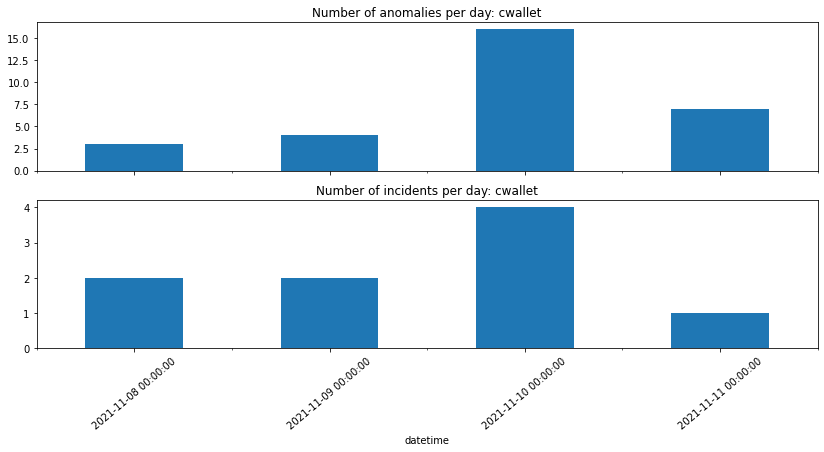

In [149]:
fig, axes = plt.subplots(2, figsize=(14,6), sharex=True)
updated_anomalies.set_index("datetime").resample("1d").count()[["timestamp"]].plot(
    kind="bar", legend=False, title=f"Number of anomalies per day: {client}", ax=axes[0]
)
incidents.set_index("datetime").resample("1d").count()[["timestamp"]].plot(
    kind="bar", legend=False, title=f"Number of incidents per day: {client}", ax=axes[1]
)
plt.xticks(rotation=40)

In [150]:
all_anomalies = pd.read_csv(
    os.path.join(DATA_DIR, "Anomalies_fp.csv"), parse_dates=["datetime"]
)

In [151]:
fp_before = all_anomalies[all_anomalies["fp"] == 1].reset_index().sort_values(by=["datetime", "source"])
fp_before

,index,datetime,source,timestamp,value,fp
0,0,2021-11-08 09:13:00,60ed840f588aa700127280d6-linux60effa84a06f3200...,1636362780,32,1
1,6,2021-11-09 01:31:00,60ed840f588aa700127280d6-linux60effafba06f3200...,1636421460,7,1
3,34,2021-11-09 09:49:00,60ed840f588aa700127280d6-linux60effb26a06f3200...,1636451340,4,1
4,35,2021-11-09 09:50:00,60ed840f588aa700127280d6-linux60effb26a06f3200...,1636451400,4,1
5,36,2021-11-09 09:51:00,60ed840f588aa700127280d6-linux60effb26a06f3200...,1636451460,4,1
6,46,2021-11-10 14:28:00,60ed840f588aa700127280d6-linux60effb30a06f3200...,1636554480,10,1
2,19,2021-11-11 06:26:00,60ed840f588aa700127280d6-linux60effb11a06f3200...,1636611960,17,1


In [157]:
updated_anomalies[updated_anomalies.source.isin(set(fp_before["source"]))].sort_values(by=["datetime", "source"])

,isAnomaly,anomaly_score,absolute_delta,timestamp,datetime,value,source
0,True,0.797216,15.944311,1636366380,2021-11-08 10:13:00,32,60ed840f588aa700127280d6-linux60effa84a06f3200...
5,True,1.000000,20.745907,1636443720,2021-11-09 07:42:00,27,60ed840f588aa700127280d6-linux60effb11a06f3200...
21,True,1.000000,51.000000,1636454880,2021-11-09 10:48:00,55,60ed840f588aa700127280d6-linux60effb26a06f3200...
22,True,1.000000,25.500000,1636454940,2021-11-09 10:49:00,4,60ed840f588aa700127280d6-linux60effb26a06f3200...
23,True,0.637500,12.750000,1636455000,2021-11-09 10:50:00,4,60ed840f588aa700127280d6-linux60effb26a06f3200...
24,True,0.833984,16.679688,1636557840,2021-11-10 15:24:00,21,60ed840f588aa700127280d6-linux60effb26a06f3200...
25,True,0.566992,11.339844,1636557900,2021-11-10 15:25:00,24,60ed840f588aa700127280d6-linux60effb26a06f3200...
26,True,1.000000,45.917480,1636558080,2021-11-10 15:28:00,70,60ed840f588aa700127280d6-linux60effb26a06f3200...
27,True,0.551031,11.020630,1636558140,2021-11-10 15:29:00,25,60ed840f588aa700127280d6-linux60effb26a06f3200...
6,True,1.000000,24.997953,1636619520,2021-11-11 08:32:00,29,60ed840f588aa700127280d6-linux60effb11a06f3200...


In [156]:
print("Overall number of detected anomalies", updated_anomalies.shape[0], sep=": ")
print("Overall number of detected anomalies per day", updated_anomalies.shape[0]/7, sep=": ")
print("Overall number of incidents", incidents.shape[0], sep=": ")
print("Overall number of incidents per day", incidents.shape[0]/7, sep=": ")

Overall number of detected anomalies: 30
Overall number of detected anomalies per day: 4.285714285714286
Overall number of incidents: 9
Overall number of incidents per day: 1.2857142857142858


In [148]:
incidents.shape

(9, 3)

In [153]:
updated_anomalies.shape

(30, 7)